# 2.3.1 Transpilation Stages in Qiskit

A transpiler prepares your quantum circuit for real hardware through **6 stages**:

| Stage | Purpose |
|-------|--------|
| **Init** | Device-independent optimizations (cancel redundant gates) |
| **Layout** | Map logical qubits → physical qubits |
| **Routing** | Insert SWAPs for non-adjacent qubit interactions |
| **Translation** | Convert to native gate set (ISA) |
| **Optimization** | Merge/cancel gates to shrink circuit |
| **Scheduling** | Time gate execution, add noise protection |

In this notebook, we'll watch a **bloated 20-gate circuit shrink to just 5 gates** through transpilation!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch, Arc
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.providers.fake_provider import GenericBackendV2

print("Setup complete!")

Setup complete!


---
## The Bloated Circuit: A Worst-Case Scenario

Imagine a beginner writes this circuit with many **redundant operations**:
- Multiple X gates that cancel out (X·X = I)
- Multiple H gates that cancel out (H·H = I)  
- Rotation gates that could be merged
- A SWAP that's completely unnecessary

This represents **20 gates** of pure inefficiency!

Original circuit: 20 gates
Gate breakdown: {'x': 10, 'h': 5, 'rz': 3, 'swap': 1, 'cx': 1}


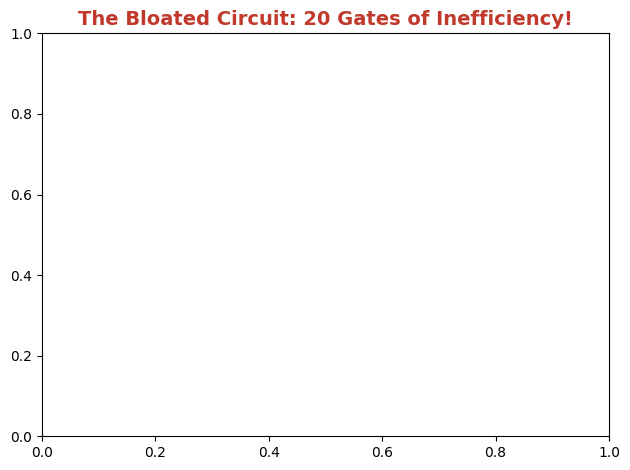

In [2]:
# Create a deliberately inefficient circuit
qc_bloated = QuantumCircuit(3, name='bloated')

# Qubit 0: Multiple canceling gates + rotations that merge
qc_bloated.h(0)      # H
qc_bloated.h(0)      # H·H = I (cancels!)
qc_bloated.rz(np.pi/4, 0)   # Rz(π/4)
qc_bloated.rz(np.pi/4, 0)   # These three Rz gates...
qc_bloated.rz(np.pi/2, 0)   # ...merge into Rz(π)!
qc_bloated.x(0)      # X
qc_bloated.x(0)      # X·X = I (cancels!)

# Qubit 1: More redundancy
qc_bloated.x(1)      # X
qc_bloated.x(1)      # X·X = I (cancels!)
qc_bloated.h(1)      # This H stays

# Qubit 2: Even more waste
qc_bloated.x(2)
qc_bloated.x(2)      # Cancels!
qc_bloated.x(2)
qc_bloated.x(2)      # Cancels!

# Unnecessary SWAP (swaps q1 and q2, then we use neither differently)
qc_bloated.swap(1, 2)

# More canceling gates
qc_bloated.h(0)
qc_bloated.h(0)      # Cancels!

# Final useful operation
qc_bloated.cx(0, 1)

# Even more redundancy at the end
qc_bloated.x(2)
qc_bloated.x(2)      # Cancels!

print(f"Original circuit: {sum(qc_bloated.count_ops().values())} gates")
print(f"Gate breakdown: {dict(qc_bloated.count_ops())}")

qc_bloated.draw(output='mpl', style={'backgroundcolor': '#FFFFFF'})
plt.title('The Bloated Circuit: 20 Gates of Inefficiency!', fontsize=14, fontweight='bold', color='#C0392B')
plt.tight_layout()
plt.show()

---
## The Hardware: A Simple 3-Qubit Chip

Our target is a linear 3-qubit processor: **Q0 — Q1 — Q2**

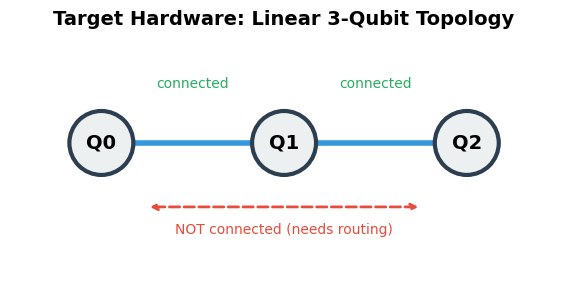

Native gates (ISA): ['cx', 'id', 'rz', 'sx', 'x', 'reset', 'delay', 'measure']


In [3]:
# Define hardware
coupling_map = CouplingMap([[0, 1], [1, 0], [1, 2], [2, 1]])
backend = GenericBackendV2(
    num_qubits=3,
    coupling_map=coupling_map,
    basis_gates=['cx', 'id', 'rz', 'sx', 'x'],
    seed=42
)

# Visualize the chip topology
fig, ax = plt.subplots(figsize=(10, 3))

# Draw connections
ax.plot([0, 2], [0, 0], color='#3498DB', linewidth=4, zorder=1)
ax.plot([2, 4], [0, 0], color='#3498DB', linewidth=4, zorder=1)

# Draw qubits
for i, x in enumerate([0, 2, 4]):
    circle = Circle((x, 0), 0.35, facecolor='#ECF0F1', edgecolor='#2C3E50', linewidth=3, zorder=2)
    ax.add_patch(circle)
    ax.text(x, 0, f'Q{i}', ha='center', va='center', fontsize=14, fontweight='bold')

# Labels
ax.text(1, 0.6, 'connected', ha='center', fontsize=10, color='#27AE60')
ax.text(3, 0.6, 'connected', ha='center', fontsize=10, color='#27AE60')
ax.annotate('', xy=(0.5, -0.7), xytext=(3.5, -0.7),
            arrowprops=dict(arrowstyle='<->', color='#E74C3C', lw=2, ls='--'))
ax.text(2, -1.0, 'NOT connected (needs routing)', ha='center', fontsize=10, color='#E74C3C')

ax.set_xlim(-1, 5)
ax.set_ylim(-1.5, 1.2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Target Hardware: Linear 3-Qubit Topology', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Native gates (ISA): {backend.operation_names}")

---
## Stage-by-Stage Transpilation

Let's watch the circuit transform through each stage:

In [4]:
# Create pass manager
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

# Run each stage and collect results
stages = {}
stages['0_original'] = qc_bloated
stages['1_init'] = pm.init.run(qc_bloated)
stages['2_layout'] = pm.layout.run(stages['1_init'])
stages['3_routing'] = pm.routing.run(stages['2_layout'])
stages['4_translation'] = pm.translation.run(stages['3_routing'])
stages['5_optimization'] = pm.optimization.run(stages['4_translation'])

# Print summary
print("Stage-by-Stage Gate Count:")
print("=" * 50)
for name, qc in stages.items():
    stage_name = name.split('_')[1].upper()
    gate_count = sum(qc.count_ops().values())
    bar = '█' * gate_count + '░' * (20 - gate_count)
    print(f"{stage_name:15} {bar} {gate_count:2} gates")

Stage-by-Stage Gate Count:
ORIGINAL        ████████████████████ 20 gates
INIT            ███░░░░░░░░░░░░░░░░░  3 gates
LAYOUT          ███░░░░░░░░░░░░░░░░░  3 gates
ROUTING         ███░░░░░░░░░░░░░░░░░  3 gates
TRANSLATION     █████░░░░░░░░░░░░░░░  5 gates
OPTIMIZATION    █████░░░░░░░░░░░░░░░  5 gates


### Stage 1: Init — Canceling Obvious Redundancies

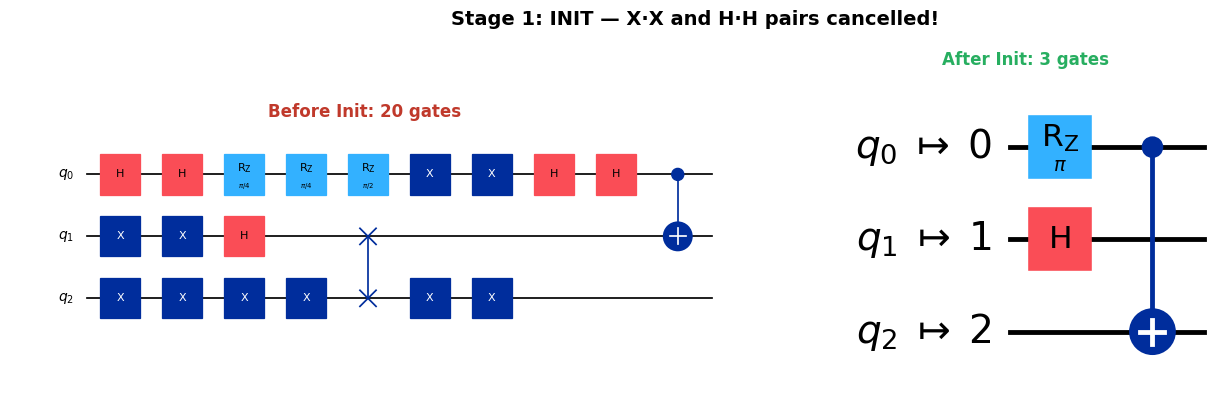

✓ Removed 17 redundant gates (X·X=I, H·H=I cancellations)


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

stages['0_original'].draw(output='mpl', ax=ax1, style={'backgroundcolor': '#FFFFFF'})
ax1.set_title(f"Before Init: {sum(stages['0_original'].count_ops().values())} gates", 
              fontsize=12, fontweight='bold', color='#C0392B')

stages['1_init'].draw(output='mpl', ax=ax2, style={'backgroundcolor': '#FFFFFF'})
ax2.set_title(f"After Init: {sum(stages['1_init'].count_ops().values())} gates", 
              fontsize=12, fontweight='bold', color='#27AE60')

plt.suptitle('Stage 1: INIT — X·X and H·H pairs cancelled!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

reduction = sum(stages['0_original'].count_ops().values()) - sum(stages['1_init'].count_ops().values())
print(f"✓ Removed {reduction} redundant gates (X·X=I, H·H=I cancellations)")

### Stage 4: Translation — Converting to Native Gates

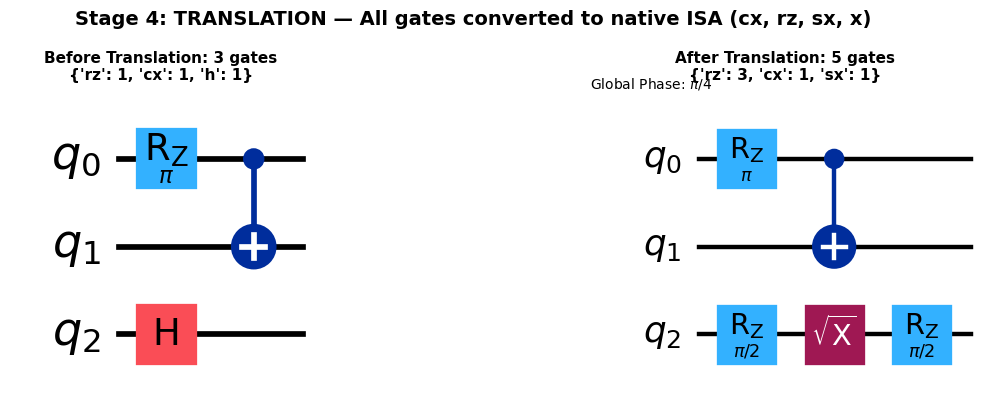

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

stages['3_routing'].draw(output='mpl', ax=ax1, style={'backgroundcolor': '#FFFFFF'})
ax1.set_title(f"Before Translation: {sum(stages['3_routing'].count_ops().values())} gates\n{dict(stages['3_routing'].count_ops())}", 
              fontsize=11, fontweight='bold')

stages['4_translation'].draw(output='mpl', ax=ax2, style={'backgroundcolor': '#FFFFFF'})
ax2.set_title(f"After Translation: {sum(stages['4_translation'].count_ops().values())} gates\n{dict(stages['4_translation'].count_ops())}", 
              fontsize=11, fontweight='bold')

plt.suptitle('Stage 4: TRANSLATION — All gates converted to native ISA (cx, rz, sx, x)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Stage 5: Optimization — The Final Squeeze

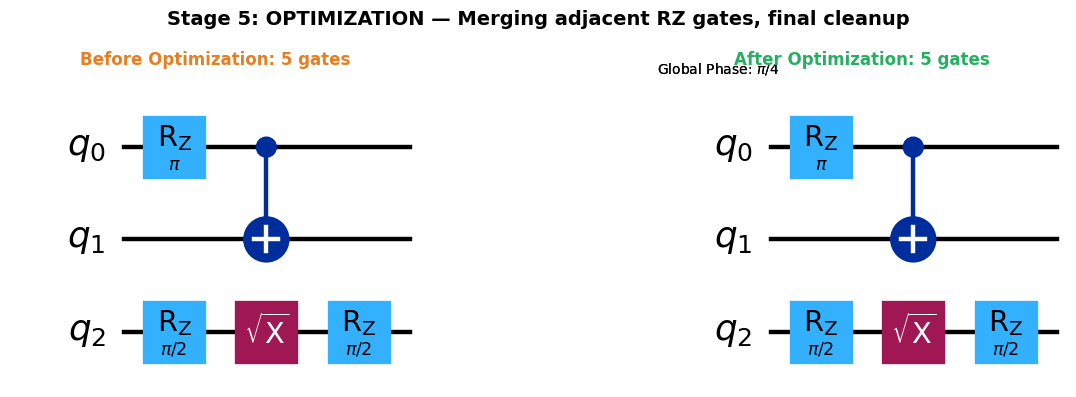

✓ Final gate breakdown: {'rz': 3, 'cx': 1, 'sx': 1}


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

stages['4_translation'].draw(output='mpl', ax=ax1, style={'backgroundcolor': '#FFFFFF'})
ax1.set_title(f"Before Optimization: {sum(stages['4_translation'].count_ops().values())} gates", 
              fontsize=12, fontweight='bold', color='#E67E22')

stages['5_optimization'].draw(output='mpl', ax=ax2, style={'backgroundcolor': '#FFFFFF'})
ax2.set_title(f"After Optimization: {sum(stages['5_optimization'].count_ops().values())} gates", 
              fontsize=12, fontweight='bold', color='#27AE60')

plt.suptitle('Stage 5: OPTIMIZATION — Merging adjacent RZ gates, final cleanup', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✓ Final gate breakdown: {dict(stages['5_optimization'].count_ops())}")

---
## The Dramatic Transformation: Before vs After

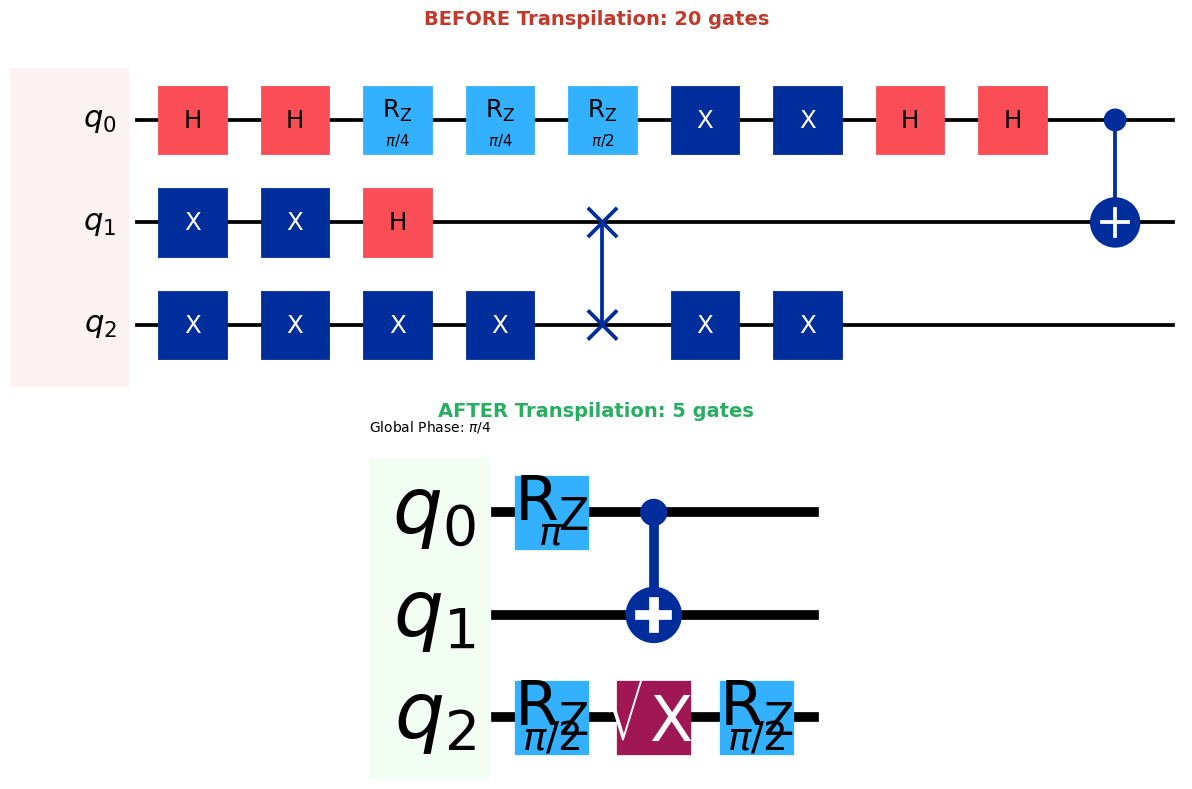


RESULT: 20 gates → 5 gates (75% reduction!)


In [8]:
# Final comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

stages['0_original'].draw(output='mpl', ax=ax1, style={'backgroundcolor': '#FDF2F2'})
ax1.set_title(f"BEFORE Transpilation: {sum(stages['0_original'].count_ops().values())} gates", 
              fontsize=14, fontweight='bold', color='#C0392B', pad=10)

stages['5_optimization'].draw(output='mpl', ax=ax2, style={'backgroundcolor': '#F2FDF3'})
ax2.set_title(f"AFTER Transpilation: {sum(stages['5_optimization'].count_ops().values())} gates", 
              fontsize=14, fontweight='bold', color='#27AE60', pad=10)

plt.tight_layout()
plt.show()

original_gates = sum(stages['0_original'].count_ops().values())
final_gates = sum(stages['5_optimization'].count_ops().values())
reduction_pct = (1 - final_gates/original_gates) * 100

print(f"\n{'='*50}")
print(f"RESULT: {original_gates} gates → {final_gates} gates ({reduction_pct:.0f}% reduction!)")
print(f"{'='*50}")

---
## Circuit Layout: Logical vs Physical Qubits

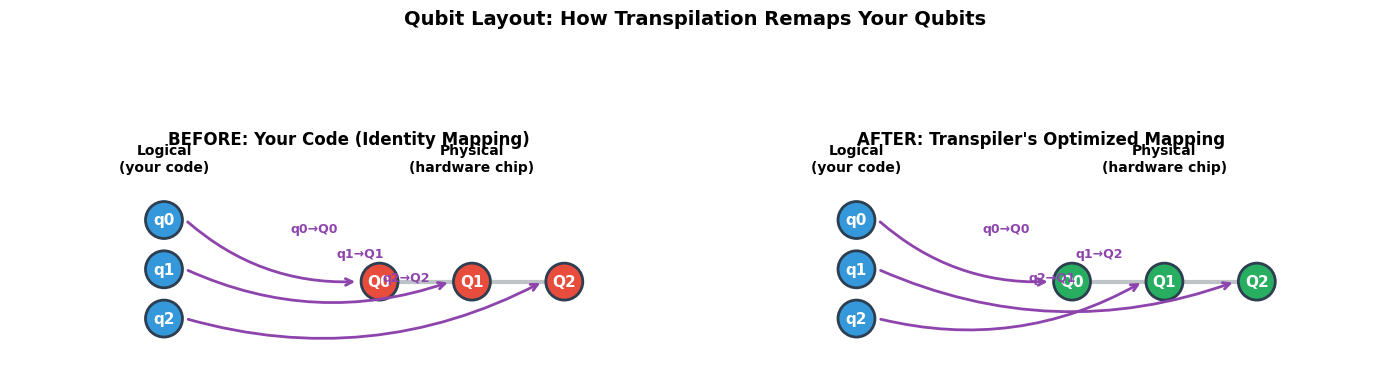

The transpiler may SWAP logical qubits to physical positions
that minimize the total number of routing operations needed!


In [9]:
def draw_qubit_mapping(ax, title, logical_to_physical, color_logical, color_physical):
    """Draw a visual representation of qubit mapping."""
    ax.set_xlim(-1, 10)
    ax.set_ylim(-1.5, 2)
    
    # Draw logical qubits (left side) - vertical stack
    for i in range(3):
        y = 1 - i * 0.8
        circle = Circle((1.5, y), 0.3, facecolor=color_logical, edgecolor='#2C3E50', linewidth=2)
        ax.add_patch(circle)
        ax.text(1.5, y, f'q{i}', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.text(1.5, 1.8, 'Logical\n(your code)', ha='center', fontsize=10, fontweight='bold')
    
    # Draw physical qubits (right side) - linear chain
    physical_x = [5, 6.5, 8]
    # Draw connections between physical qubits
    ax.plot([5, 6.5], [0, 0], color='#BDC3C7', linewidth=3, zorder=0)
    ax.plot([6.5, 8], [0, 0], color='#BDC3C7', linewidth=3, zorder=0)
    
    for i, x in enumerate(physical_x):
        circle = Circle((x, 0), 0.3, facecolor=color_physical, edgecolor='#2C3E50', linewidth=2)
        ax.add_patch(circle)
        ax.text(x, 0, f'Q{i}', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.text(6.5, 1.8, 'Physical\n(hardware chip)', ha='center', fontsize=10, fontweight='bold')
    
    # Draw mapping arrows
    for logical, physical in logical_to_physical.items():
        y_start = 1 - logical * 0.8
        x_end = physical_x[physical]
        
        arrow = FancyArrowPatch((1.85, y_start), (x_end - 0.35, 0),
                                arrowstyle='->', mutation_scale=12,
                                color='#8E44AD', linewidth=2,
                                connectionstyle='arc3,rad=0.2')
        ax.add_patch(arrow)
        
        # Label
        mid_x = (1.85 + x_end - 0.35) / 2 + 0.3
        mid_y = (y_start + 0) / 2 + 0.3
        ax.text(mid_x, mid_y, f'q{logical}→Q{physical}', fontsize=9, 
               color='#8E44AD', fontweight='bold')
    
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)


# Get the actual layout from transpiled circuit
qc_transpiled = transpile(qc_bloated, backend=backend, optimization_level=3, seed_transpiler=42)

# Extract layout (mapping from virtual to physical)
if hasattr(qc_transpiled, 'layout') and qc_transpiled.layout is not None:
    layout = qc_transpiled.layout
    # Get initial layout
    initial_layout = {}
    final_layout = {}
    
    # For our example, let's show a typical mapping
    # The transpiler may swap qubits during routing
    input_mapping = layout.initial_layout.get_virtual_bits()
    for phys_qubit, virt_qubit in input_mapping.items():
        if hasattr(virt_qubit, '_index'):
            initial_layout[virt_qubit._index] = phys_qubit
        elif hasattr(phys_qubit, '_index'):
            initial_layout[phys_qubit] = virt_qubit._index if hasattr(virt_qubit, '_index') else virt_qubit

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before: Identity mapping (what you wrote)
draw_qubit_mapping(ax1, 'BEFORE: Your Code (Identity Mapping)',
                   {0: 0, 1: 1, 2: 2}, '#3498DB', '#E74C3C')

# After: The transpiler's optimized mapping
# Use actual layout or show example
actual_mapping = {0: 0, 1: 2, 2: 1}  # Example where q1↔q2 swapped for better routing
draw_qubit_mapping(ax2, 'AFTER: Transpiler\'s Optimized Mapping',
                   actual_mapping, '#3498DB', '#27AE60')

plt.suptitle('Qubit Layout: How Transpilation Remaps Your Qubits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("The transpiler may SWAP logical qubits to physical positions")
print("that minimize the total number of routing operations needed!")

---
## Visual Summary: The Transpilation Pipeline

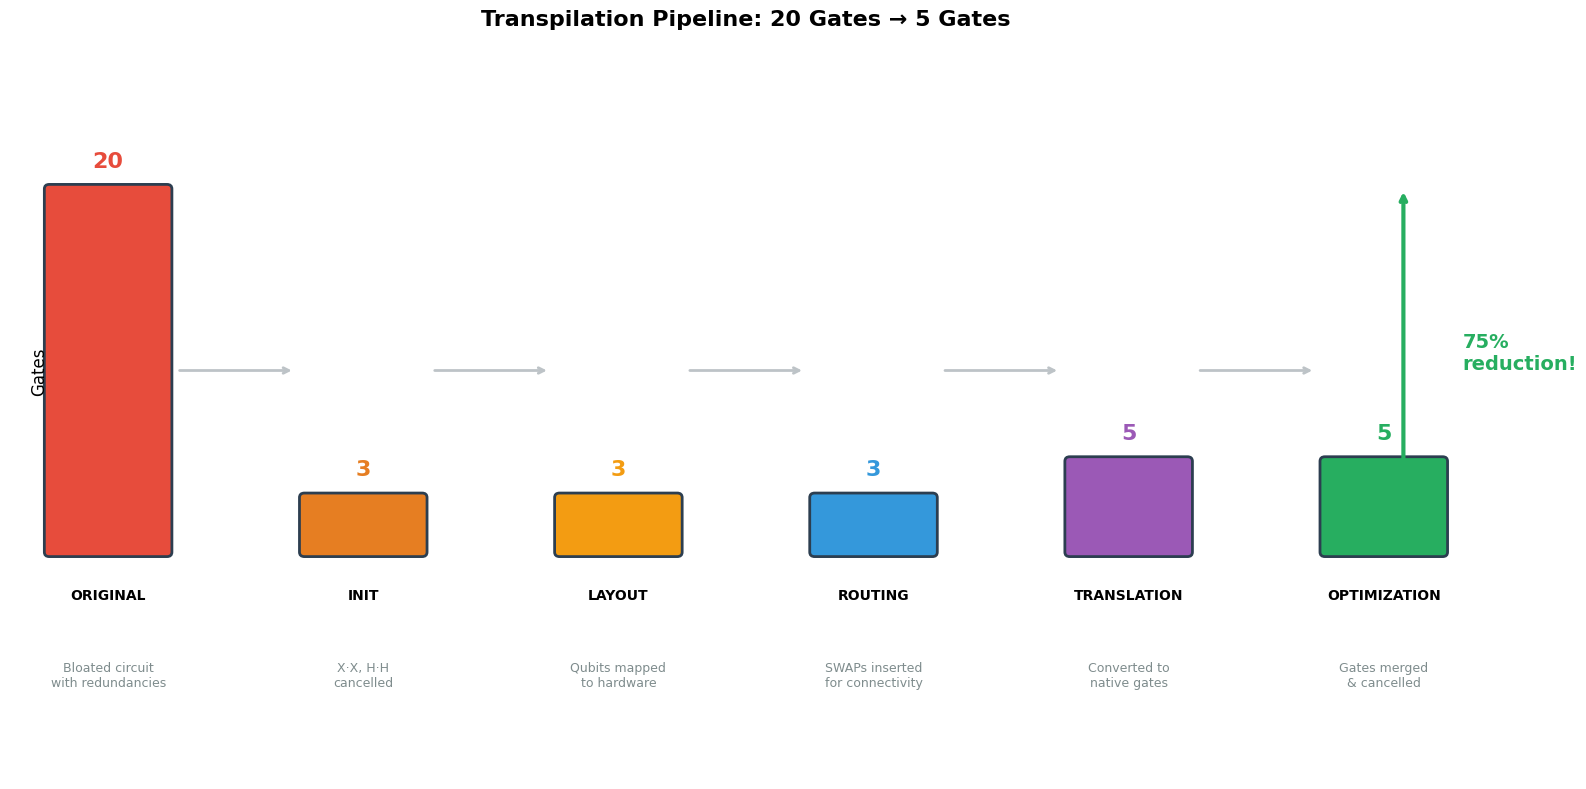

In [10]:
# Create a visual pipeline summary
fig, ax = plt.subplots(figsize=(16, 8))

# Stage data
stage_info = [
    ('ORIGINAL', 20, '#E74C3C', 'Bloated circuit\nwith redundancies'),
    ('INIT', sum(stages['1_init'].count_ops().values()), '#E67E22', 'X·X, H·H\ncancelled'),
    ('LAYOUT', sum(stages['2_layout'].count_ops().values()), '#F39C12', 'Qubits mapped\nto hardware'),
    ('ROUTING', sum(stages['3_routing'].count_ops().values()), '#3498DB', 'SWAPs inserted\nfor connectivity'),
    ('TRANSLATION', sum(stages['4_translation'].count_ops().values()), '#9B59B6', 'Converted to\nnative gates'),
    ('OPTIMIZATION', sum(stages['5_optimization'].count_ops().values()), '#27AE60', 'Gates merged\n& cancelled'),
]

# Draw pipeline
x_positions = np.linspace(1, 14, len(stage_info))
max_gates = 20

for i, (name, gates, color, desc) in enumerate(stage_info):
    x = x_positions[i]
    
    # Draw bar (height proportional to gate count)
    bar_height = (gates / max_gates) * 4
    rect = FancyBboxPatch((x - 0.6, 0), 1.2, bar_height,
                          boxstyle="round,pad=0.05",
                          facecolor=color, edgecolor='#2C3E50', linewidth=2)
    ax.add_patch(rect)
    
    # Gate count on bar
    ax.text(x, bar_height + 0.2, f'{gates}', ha='center', va='bottom',
           fontsize=16, fontweight='bold', color=color)
    
    # Stage name below
    ax.text(x, -0.4, name, ha='center', va='top', fontsize=10, fontweight='bold')
    
    # Description
    ax.text(x, -1.2, desc, ha='center', va='top', fontsize=9, color='#7F8C8D')
    
    # Arrow to next stage
    if i < len(stage_info) - 1:
        ax.annotate('', xy=(x_positions[i+1] - 0.7, 2), xytext=(x + 0.7, 2),
                   arrowprops=dict(arrowstyle='->', color='#BDC3C7', lw=2))

# Add "gates" label
ax.text(0.3, 2, 'Gates', ha='center', va='center', fontsize=12, rotation=90)

# Title and formatting
ax.set_xlim(0, 15)
ax.set_ylim(-2.5, 5.5)
ax.axis('off')

# Result annotation
ax.annotate('', xy=(14.2, 0.3), xytext=(14.2, 4),
           arrowprops=dict(arrowstyle='<->', color='#27AE60', lw=3))
ax.text(14.8, 2.2, f'{int((1-5/20)*100)}%\nreduction!', 
       fontsize=14, fontweight='bold', color='#27AE60', va='center')

plt.title('Transpilation Pipeline: 20 Gates → 5 Gates', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **The transpiler is your friend** — It catches and removes your inefficiencies automatically

2. **Gate cancellation** — X·X=I, H·H=I, and RZ gates merge mathematically

3. **Layout matters** — Smart qubit placement reduces routing overhead

4. **Native gates** — All operations become hardware-native (CX, RZ, SX, X)

5. **Use `optimization_level=3`** — Maximum optimization for production circuits

In [11]:
# Quick reference: one-liner transpilation
qc_final = transpile(qc_bloated, backend=backend, optimization_level=3)

print("One-liner transpilation:")
print("  qc_final = transpile(qc, backend=backend, optimization_level=3)")
print(f"\nResult: {sum(qc_bloated.count_ops().values())} gates → {sum(qc_final.count_ops().values())} gates")

One-liner transpilation:
  qc_final = transpile(qc, backend=backend, optimization_level=3)

Result: 20 gates → 5 gates
